# DrugReview R1 — ALBERT Multi-Task Aspect Model (Efficacy + Safety)

One shared **ALBERT** backbone with two 3-class aspect heads (`ai_efficacy`, `ai_safety`). One of **four parallel notebooks** = 2 cohorts x {without, with} metadata.

Conventions follow the canonical Manuscript 3 DrugReview pipeline (`NLP-LLM-Evaluation/Manuscript3/03_Hard_Label_Primary/DrugReview_Aspect_*`): GroupShuffleSplit (rs=42) on review text, **metadata textualized into `model_text`** for the DL model, balanced-weighted cross-entropy, AutoTokenizer, FP16 + OneCycleLR + grad-clip, and classification-report / bootstrap-CI / ROC evaluation.

## 1. Setup

In [ ]:
# @cell:pipinstall
# Colab usually ships torch + transformers. Uncomment if needed:
# !pip install -q transformers

In [ ]:
# @cell:imports
import os, re, gc, json, time, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             roc_auc_score, roc_curve, auc, accuracy_score)
from sklearn.preprocessing import label_binarize
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import OneCycleLR
try:
    from torch.amp import autocast, GradScaler
except Exception:
    from torch.cuda.amp import autocast, GradScaler
from transformers import AutoTokenizer, AlbertModel

warnings.filterwarnings('ignore')

In [ ]:
# @cell:seed
SEED = 2025
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed()
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


## 1.1 Configuration

In [ ]:
# @cell:config
# ============================================================
#  RUN CONFIGURATION  (only cell that differs across the 4 notebooks)
# ============================================================
COHORT       = "mood_anxiety"          # mood_anxiety | heterogeneous
USE_METADATA = False      # False = review only | True = metadata textualized into model_text
RUN_ID       = "T51_mood_anxiety_without_metadata"
CSV_NAME     = "drugsCom_mood_anxiety_with_ai_labels_mini.csv"

# ---- Aspect heads: joint efficacy + safety, 3-class each ----
ASPECT_NAMES       = ["ai_efficacy", "ai_safety"]
ASPECT_CLASSES     = ["NEGATIVE", "NEUTRAL", "POSITIVE"]
NUM_ASPECT_CLASSES = len(ASPECT_CLASSES)
ASPECT_LABEL_MAP   = {v: i for i, v in enumerate(ASPECT_CLASSES)}

TEXT_COLUMN0 = "review"       # raw review column
ALBERT_MODEL_NAME = "albert-base-v2"

# ---- Training (Manuscript 3 canonical) ----
MAX_TOKEN_LENGTH = 200
BATCH_SIZE       = 128
N_ITERATIONS     = 10
PATIENCE         = 3
RANDOM_STATE     = 42          # GroupShuffleSplit seed
MAX_GRAD_NORM    = 1.0
RETRAIN          = True

USE_FP16       = torch.cuda.is_available()
TORCH_COMPILE_OK = hasattr(torch, "compile")

# ---- Paths: one experiment folder holds data/ and outputs/ ----
EXPERIMENT_ROOT = Path("./R1/T51_mood_anxiety_without_metadata")
DATA_PATH   = EXPERIMENT_ROOT / "data" / CSV_NAME
OUTPUT_PATH = EXPERIMENT_ROOT / "outputs"
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

def resolve_data_path():      # path is fixed; kept so the load cell runs unchanged
    return DATA_PATH

print("COHORT       =", COHORT)
print("USE_METADATA =", USE_METADATA)
print("ASPECTS      =", ASPECT_NAMES)
print("DATA_PATH    =", DATA_PATH)
print("OUTPUT_PATH  =", OUTPUT_PATH)


COHORT       = mood_anxiety
USE_METADATA = False
ASPECTS      = ['ai_efficacy', 'ai_safety']
DATA_PATH    = ./R1/T51_mood_anxiety_without_metadata/data/drugsCom_mood_anxiety_with_ai_labels_mini.csv
OUTPUT_PATH  = ./R1/T51_mood_anxiety_without_metadata/outputs


## 1.2 Mount Drive & load data

In [ ]:
# @cell:mount
import os
if os.path.ismount("/content/drive"):
    # Already mounted, skip
    pass
else:
    !fusermount -u /content/drive 2>/dev/null
    # [sanitized] removed destructive Drive wipe
    from google.colab import drive
    drive.mount("/content/drive/", force_remount=True)

Mounted at /content/drive/


In [ ]:
# @cell:load
DATA_PATH = resolve_data_path()
df_raw = pd.read_csv(DATA_PATH)
print(f'Loaded {len(df_raw):,} rows from {DATA_PATH}')
df_raw.head()

Loaded 28,755 rows from ./R1/T51_mood_anxiety_without_metadata/data/drugsCom_mood_anxiety_with_ai_labels_mini.csv


,drugName,condition,review,rating,date,usefulCount,condition_clean,sentiment_5,ai_rating_10,ai_sentiment_5,ai_efficacy,ai_safety,ai_raw_json_mini,ai_prob_very_negative,ai_prob_negative,ai_prob_neutral,ai_prob_positive,ai_prob_very_positive
0,L-methylfolate,Depression,"""I have taken anti-depressants for years, with...",10,9-Mar-17,54,Depression,very_positive,10.0,VERY_POSITIVE,POSITIVE,POSITIVE,"[\n {\n ""index"": 0,\n ""ai_rat...",0.0,0.0,0.0,0.0,1.0
1,Ativan,Panic Disorde,"""Honestly, I have been taking ativan for 2 yea...",6,1-Jun-15,47,Panic Disorde,neutral,6.0,NEUTRAL,NEUTRAL,NEUTRAL,"[\n {\n ""index"": 0,\n ""ai_rat...",0.0,0.1,0.4,0.5,0.0
2,Sertraline,Depression,"""1 week on Zoloft for anxiety and mood swings....",8,7-May-11,3,Depression,positive,7.0,POSITIVE,POSITIVE,NEUTRAL,"[\n {\n ""index"": 0,\n ""ai_rat...",0.0,0.1,0.2,0.5,0.2
3,Clonazepam,Panic Disorde,"""This medication changed my life. My panic at...",9,1-Apr-08,30,Panic Disorde,very_positive,10.0,VERY_POSITIVE,POSITIVE,POSITIVE,"[\n {\n ""index"": 0,\n ""ai_rat...",0.0,0.0,0.0,0.0,1.0
4,Venlafaxine,Depression,"""my gp started me on Venlafaxine yesterday to ...",4,27-Apr-16,3,Depression,negative,2.0,VERY_NEGATIVE,NEGATIVE,NEGATIVE,"[\n {\n ""index"": 0,\n ""ai_rat...",0.5,0.3,0.1,0.1,0.0


## 2. Build model text (metadata textualized for the DL model) & clean

In [ ]:
# @cell:modeltext
def normalize_meta(series):
    return (series.fillna('').astype(str).str.strip().str.lower()
            .str.replace(r'\s+', ' ', regex=True))

df = df_raw.copy()
df['drug_norm'] = normalize_meta(df['drugName']) if 'drugName' in df.columns else ''
if 'condition_clean' in df.columns:
    _cond = df['condition_clean'].where(df['condition_clean'].notna(), df.get('condition'))
else:
    _cond = df.get('condition')
df['condition_norm'] = normalize_meta(_cond) if _cond is not None else ''
df['useful_num'] = pd.to_numeric(df.get('usefulCount'), errors='coerce').fillna(0).astype(int)

# DL convention (Manuscript 3): textualize metadata into the input for the 'with metadata' runs;
# text-only runs feed the raw review. Field markers ([DRUG]/[COND]/[USEFUL]/[TEXT]) become
# plain marker words after clean_text strips brackets.
def build_model_text(r):
    return (f"[DRUG] {r['drug_norm']} [COND] {r['condition_norm']} "
            f"[USEFUL] {r['useful_num']} [TEXT] {r[TEXT_COLUMN0]}")

if USE_METADATA:
    df['model_text'] = df.apply(build_model_text, axis=1)
else:
    df['model_text'] = df[TEXT_COLUMN0].fillna('').astype(str)
print('Example model_text:\n', df['model_text'].iloc[0][:200])

Example model_text:
 "I have taken anti-depressants for years, with some improvement but mostly moderate to severe side affects, which makes me go off them.

I only take Cymbalta now mostly for pain.

When I began Dep


In [ ]:
# @cell:clean
def clean_text(text):
    if pd.isna(text):
        return ''
    text = str(text).lower()
    text = re.sub(r'http\S+', ' urltoken ', text)
    text = re.sub(r'@\w+', ' usertoken ', text)
    text = re.sub(r'#(\w+)', r' hashtag_\1 ', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['text_clean'] = df['model_text'].apply(clean_text)
# review-level group key (never let the same review span splits)
df['group_key'] = (df[TEXT_COLUMN0].fillna('').astype(str).str.lower()
                   .str.replace(r'\s+', ' ', regex=True).str.strip())
print('Cleaned', len(df), 'rows')

Cleaned 28755 rows


In [ ]:
# @cell:labels
print('Aspect label distributions:')
for asp in ASPECT_NAMES:
    if asp not in df.columns:
        raise ValueError(f'Missing aspect column: {asp}')
    df[asp] = df[asp].astype(str).str.upper().str.strip()
    df[asp] = df[asp].replace({'VERY_POSITIVE': 'POSITIVE', 'VERY_NEGATIVE': 'NEGATIVE'})
    bad = ~df[asp].isin(ASPECT_CLASSES)
    if bad.any():
        print(f'  {asp}: {int(bad.sum())} invalid -> NEUTRAL')
        df.loc[bad, asp] = 'NEUTRAL'
    df[f'{asp}_idx'] = df[asp].map(ASPECT_LABEL_MAP).astype(np.int64)
    print(f'  {asp}: {df[asp].value_counts().to_dict()}')

Aspect label distributions:
  ai_efficacy: {'POSITIVE': 19503, 'NEGATIVE': 6485, 'NEUTRAL': 2767}
  ai_safety: {'NEGATIVE': 10860, 'NEUTRAL': 10472, 'POSITIVE': 7423}


## 2.1 Group split (60 / 20 / 20, rs=42) — no review leaks across splits

In [ ]:
# @cell:split
groups  = df['group_key'].to_numpy()
y_strat = df[f'{ASPECT_NAMES[0]}_idx'].to_numpy()

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
trainval_idx, test_idx = next(gss1.split(df, y_strat, groups=groups))
split = np.array(['train'] * len(df), dtype=object)
split[test_idx] = 'test'

df_tv = df.iloc[trainval_idx].reset_index(drop=True)
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
_tr, _va = next(gss2.split(df_tv, df_tv[f'{ASPECT_NAMES[0]}_idx'], groups=df_tv['group_key']))
split[trainval_idx[_va]] = 'val'
df['split'] = split

print('Split counts:'); print(df['split'].value_counts())
n_leak = int((df.groupby('group_key')['split'].nunique() > 1).sum())
assert n_leak == 0, f'{n_leak} review groups leak across splits!'
print('Group-split leakage check passed (0 reviews span splits).')

Split counts:
split
train    17221
test      5773
val       5761
Name: count, dtype: int64
Group-split leakage check passed (0 reviews span splits).


In [ ]:
# @cell:splitframes
df_train = df[df.split == 'train'].reset_index(drop=True)
df_val   = df[df.split == 'val'].reset_index(drop=True)
df_test  = df[df.split == 'test'].reset_index(drop=True)

train_texts = df_train['text_clean'].tolist()
val_texts   = df_val['text_clean'].tolist()
test_texts  = df_test['text_clean'].tolist()

y_train = {a: df_train[f'{a}_idx'].to_numpy() for a in ASPECT_NAMES}
y_val   = {a: df_val[f'{a}_idx'].to_numpy()   for a in ASPECT_NAMES}
y_test  = {a: df_test[f'{a}_idx'].to_numpy()  for a in ASPECT_NAMES}

# Balanced class weights per aspect (Manuscript 3 DL convention)
aspect_weights = {}
for a in ASPECT_NAMES:
    uniq = np.unique(y_train[a])
    w = compute_class_weight('balanced', classes=uniq, y=y_train[a])
    full = np.ones(NUM_ASPECT_CLASSES, dtype=np.float32)
    for cid, wi in zip(uniq, w):
        full[cid] = wi
    aspect_weights[a] = torch.tensor(full, dtype=torch.float32).to(DEVICE)
    print(a, 'class weights:', full.round(3))
print('Train/Val/Test:', len(df_train), len(df_val), len(df_test))

ai_efficacy class weights: [1.487 3.427 0.491]
ai_safety class weights: [0.891 0.914 1.276]
Train/Val/Test: 17221 5761 5773


## 3. Tokenize, dataset & ALBERT multi-task model

In [ ]:
# @cell:dataset
tokenizer = AutoTokenizer.from_pretrained(ALBERT_MODEL_NAME)

def batch_tokenize(texts, max_len=MAX_TOKEN_LENGTH, chunk=512):
    ids, masks = [], []
    for i in range(0, len(texts), chunk):
        enc = tokenizer([str(t) for t in texts[i:i+chunk]], max_length=max_len,
                        truncation=True, padding='max_length', return_tensors='pt')
        ids.append(enc['input_ids']); masks.append(enc['attention_mask'])
    return torch.cat(ids), torch.cat(masks)

class AspectDataset(Dataset):
    def __init__(self, input_ids, masks, labels):
        self.input_ids = input_ids; self.masks = masks
        self.labels = {a: torch.tensor(np.asarray(v, dtype=np.int64)) for a, v in labels.items()}
    def __len__(self):
        return self.input_ids.shape[0]
    def __getitem__(self, i):
        item = {'input_ids': self.input_ids[i], 'attention_mask': self.masks[i]}
        for a in ASPECT_NAMES:
            item[f'{a}_label'] = self.labels[a][i]
        return item

print('Tokenizing...')
tr_ids, tr_m = batch_tokenize(train_texts)
va_ids, va_m = batch_tokenize(val_texts)
te_ids, te_m = batch_tokenize(test_texts)

loader_kw = dict(batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
train_loader = DataLoader(AspectDataset(tr_ids, tr_m, y_train), shuffle=True,  **loader_kw)
val_loader   = DataLoader(AspectDataset(va_ids, va_m, y_val),   shuffle=False, **loader_kw)
test_loader  = DataLoader(AspectDataset(te_ids, te_m, y_test),  shuffle=False, **loader_kw)
print('Loaders ready.')

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

Tokenizing...
Loaders ready.


In [ ]:
# @cell:model
class AspectALBERT(nn.Module):
    """Shared ALBERT backbone ([CLS]) + one 3-class head per aspect."""
    def __init__(self, model_name, dropout=0.1):
        super().__init__()
        self.base = AlbertModel.from_pretrained(model_name)
        hidden = self.base.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.heads = nn.ModuleDict({a: nn.Linear(hidden, NUM_ASPECT_CLASSES) for a in ASPECT_NAMES})
    def forward(self, input_ids, attention_mask):
        out = self.base(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.dropout(out.last_hidden_state[:, 0, :])
        return {a: head(cls) for a, head in self.heads.items()}

## 4. Training (FP16 + OneCycleLR + grad-clip; random search)

In [ ]:
# @cell:train
def train_albert(model, train_loader, val_loader, lr=2e-5, max_epochs=6, patience=PATIENCE):
    model.to(DEVICE)
    if TORCH_COMPILE_OK:
        try:
            model = torch.compile(model, mode='reduce-overhead')
        except Exception:
            pass
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    total_steps = max_epochs * max(1, len(train_loader))
    scheduler = OneCycleLR(optimizer, max_lr=lr, total_steps=total_steps, pct_start=0.1)
    criteria = {a: nn.CrossEntropyLoss(weight=aspect_weights[a]) for a in ASPECT_NAMES}
    scaler = GradScaler(enabled=USE_FP16)
    best_f1, best_state, best_ep, stale = -1.0, None, -1, 0
    for epoch in range(1, max_epochs + 1):
        model.train(); losses = []
        for batch in train_loader:
            ids = batch['input_ids'].to(DEVICE, non_blocking=True)
            mask = batch['attention_mask'].to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with autocast('cuda', enabled=USE_FP16):
                logits = model(ids, mask)
                loss = sum(criteria[a](logits[a], batch[f'{a}_label'].to(DEVICE)) for a in ASPECT_NAMES)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scaler.step(optimizer); scaler.update(); scheduler.step()
            losses.append(loss.item())
        model.eval(); vt = {a: [] for a in ASPECT_NAMES}; vp = {a: [] for a in ASPECT_NAMES}
        with torch.no_grad():
            for batch in val_loader:
                ids = batch['input_ids'].to(DEVICE, non_blocking=True)
                mask = batch['attention_mask'].to(DEVICE, non_blocking=True)
                with autocast('cuda', enabled=USE_FP16):
                    logits = model(ids, mask)
                for a in ASPECT_NAMES:
                    vp[a].extend(logits[a].float().argmax(1).cpu().numpy())
                    vt[a].extend(batch[f'{a}_label'].numpy())
        f1s = {a: f1_score(vt[a], vp[a], average='weighted') for a in ASPECT_NAMES}
        mean_f1 = float(np.mean(list(f1s.values())))
        print(f'  epoch {epoch}/{max_epochs} loss={np.mean(losses):.4f} meanF1={mean_f1:.4f} ' +
              ' '.join(f"{a.replace('ai_','')}={f1s[a]:.3f}" for a in ASPECT_NAMES))
        raw = model._orig_mod if hasattr(model, '_orig_mod') else model
        if mean_f1 > best_f1:
            best_f1 = mean_f1
            best_state = {k: v.cpu().clone() for k, v in raw.state_dict().items()}
            best_ep = epoch; stale = 0
        else:
            stale += 1
            if stale >= patience:
                print('  early stop'); break
    raw = model._orig_mod if hasattr(model, '_orig_mod') else model
    if best_state is not None:
        raw.load_state_dict(best_state)
    return best_f1, raw, best_ep

In [ ]:
# @cell:search
MODEL_PATH  = OUTPUT_PATH / 'best_albert_aspect.pth'
PARAMS_PATH = OUTPUT_PATH / 'best_albert_aspect_params.json'

if RETRAIN:
    set_seed(); start = time.time()
    space = {'lr': (np.log10(1e-5), np.log10(3e-5)), 'epochs': (4, 10), 'dropout': (0.0, 0.25)}
    best_f1, best_params, best_model = 0.0, None, None
    for it in tqdm(range(N_ITERATIONS), desc=f'ALBERT search [{RUN_ID}]'):
        hp = {'lr': float(10 ** np.random.uniform(*space['lr'])),
              'epochs': int(np.random.randint(*space['epochs'])),
              'dropout': float(np.random.uniform(*space['dropout']))}
        model = AspectALBERT(ALBERT_MODEL_NAME, dropout=hp['dropout'])
        f1v, model, ep = train_albert(model, train_loader, val_loader,
                                      lr=hp['lr'], max_epochs=hp['epochs'])
        if f1v > best_f1:
            best_f1, best_params, best_model = f1v, {**hp, 'best_epoch': ep}, model
            torch.save(model.state_dict(), MODEL_PATH)
        del model; gc.collect(); torch.cuda.empty_cache()
    json.dump(best_params, open(PARAMS_PATH, 'w'), indent=2)
    print(f'Best val mean-F1 = {best_f1:.4f} | params = {best_params} | {time.time()-start:.0f}s')
else:
    best_params = json.load(open(PARAMS_PATH))
    best_model = AspectALBERT(ALBERT_MODEL_NAME, dropout=best_params.get('dropout', 0.1))
    best_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
best_model.to(DEVICE).eval()
print('Best model ready.')

ALBERT search [T51_mood_anxiety_without_metadata]:   0%|          | 0/10 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

[transformers] AlbertModel LOAD REPORT from: albert-base-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
predictions.dense.weight     | UNEXPECTED |  | 
predictions.decoder.bias     | UNEXPECTED |  | 
predictions.LayerNorm.weight | UNEXPECTED |  | 
predictions.dense.bias       | UNEXPECTED |  | 
predictions.bias             | UNEXPECTED |  | 
predictions.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  epoch 1/6 loss=1.8791 meanF1=0.6986 efficacy=0.797 safety=0.600
  epoch 2/6 loss=1.2139 meanF1=0.7526 efficacy=0.821 safety=0.684
  epoch 3/6 loss=0.9605 meanF1=0.7697 efficacy=0.828 safety=0.711
  epoch 4/6 loss=0.7894 meanF1=0.7850 efficacy=0.847 safety=0.723
  epoch 5/6 loss=0.6703 meanF1=0.7856 efficacy=0.857 safety=0.714
  epoch 6/6 loss=0.6068 meanF1=0.7835 efficacy=0.855 safety=0.712


...

[transformers] AlbertModel LOAD REPORT from: albert-base-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
predictions.dense.weight     | UNEXPECTED |  | 
predictions.decoder.bias     | UNEXPECTED |  | 
predictions.LayerNorm.weight | UNEXPECTED |  | 
predictions.dense.bias       | UNEXPECTED |  | 
predictions.bias             | UNEXPECTED |  | 
predictions.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  epoch 1/6 loss=1.7481 meanF1=0.7095 efficacy=0.828 safety=0.591
  epoch 2/6 loss=1.1835 meanF1=0.7811 efficacy=0.839 safety=0.723
  epoch 3/6 loss=0.9434 meanF1=0.7736 efficacy=0.863 safety=0.684
  epoch 4/6 loss=0.7635 meanF1=0.7914 efficacy=0.856 safety=0.727
  epoch 5/6 loss=0.6195 meanF1=0.7959 efficacy=0.865 safety=0.727
  epoch 6/6 loss=0.5393 meanF1=0.7945 efficacy=0.861 safety=0.728


Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

[transformers] AlbertModel LOAD REPORT from: albert-base-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
predictions.dense.weight     | UNEXPECTED |  | 
predictions.decoder.bias     | UNEXPECTED |  | 
predictions.LayerNorm.weight | UNEXPECTED |  | 
predictions.dense.bias       | UNEXPECTED |  | 
predictions.bias             | UNEXPECTED |  | 
predictions.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  epoch 1/9 loss=1.9271 meanF1=0.7349 efficacy=0.786 safety=0.684
  epoch 2/9 loss=1.1516 meanF1=0.7543 efficacy=0.848 safety=0.660
  epoch 3/9 loss=0.8951 meanF1=0.7805 efficacy=0.829 safety=0.732
  epoch 4/9 loss=0.7234 meanF1=0.7909 efficacy=0.865 safety=0.716
  epoch 5/9 loss=0.5913 meanF1=0.8001 efficacy=0.865 safety=0.735
  epoch 6/9 loss=0.4838 meanF1=0.7955 efficacy=0.870 safety=0.721
  epoch 7/9 loss=0.3950 meanF1=0.7973 efficacy=0.869 safety=0.726
  epoch 8/9 loss=0.3379 meanF1=0.7997 efficacy=0.871 safety=0.728
  early stop
Best val mean-F1 = 0.8001 | params = {'lr': 2.9768448441450054e-05, 'epochs': 9, 'dropout': 0.2365358833708563, 'best_epoch': 5} | 1866s
Best model ready.


## 5. Evaluation (per aspect: report, bootstrap F1 CI, confusion, ROC, macro AUC)

ai_efficacy   (3-class: NEGATIVE / NEUTRAL / POSITIVE)
              precision    recall  f1-score   support

    NEGATIVE     0.8779    0.7624    0.8161      1292
     NEUTRAL     0.3986    0.6692    0.4996       520
    POSITIVE     0.9500    0.9061    0.9275      3961

    accuracy                         0.8526      5773
   macro avg     0.7422    0.7792    0.7477      5773
weighted avg     0.8842    0.8526    0.8640      5773

Accuracy       : 0.8526
Macro F1       : 0.7477
Weighted F1    : 0.8644  95% CI [0.8562, 0.8727]
Macro AUC (OvR): 0.9503  95% CI [0.9454, 0.9552]


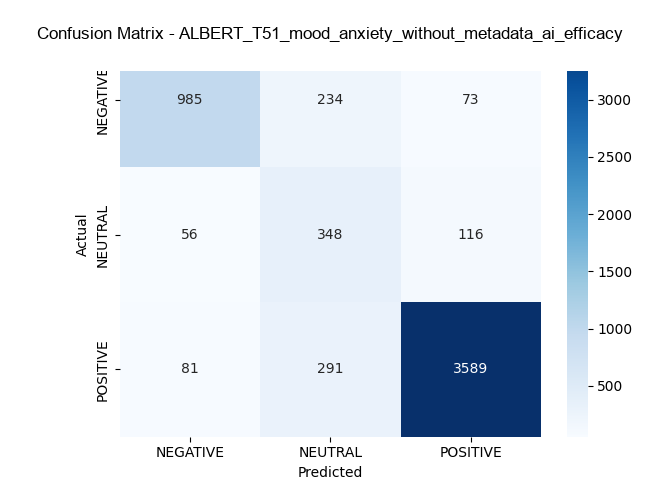

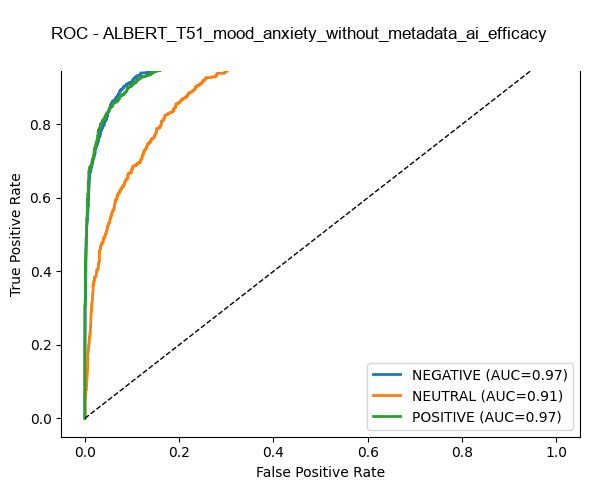

ai_safety   (3-class: NEGATIVE / NEUTRAL / POSITIVE)
              precision    recall  f1-score   support

    NEGATIVE     0.8182    0.8052    0.8117      2213
     NEUTRAL     0.6305    0.6659    0.6477      2071
    POSITIVE     0.7280    0.6884    0.7076      1489

    accuracy                         0.7251      5773
   macro avg     0.7256    0.7198    0.7223      5773
weighted avg     0.7276    0.7251    0.7260      5773

Accuracy       : 0.7251
Macro F1       : 0.7223
Weighted F1    : 0.7261  95% CI [0.7137, 0.7383]
Macro AUC (OvR): 0.8901  95% CI [0.8838, 0.8963]


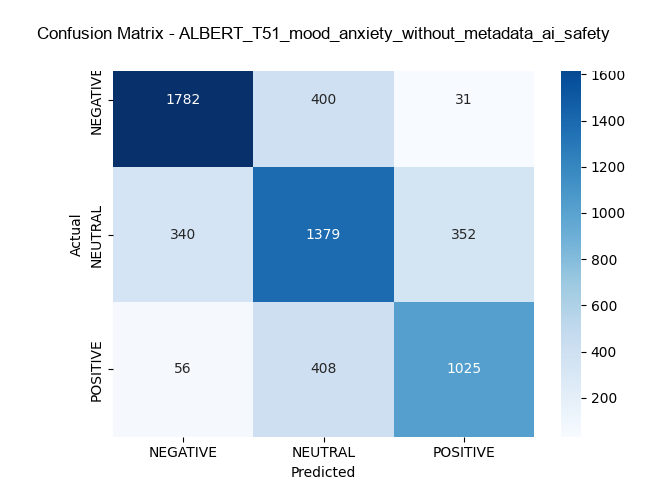

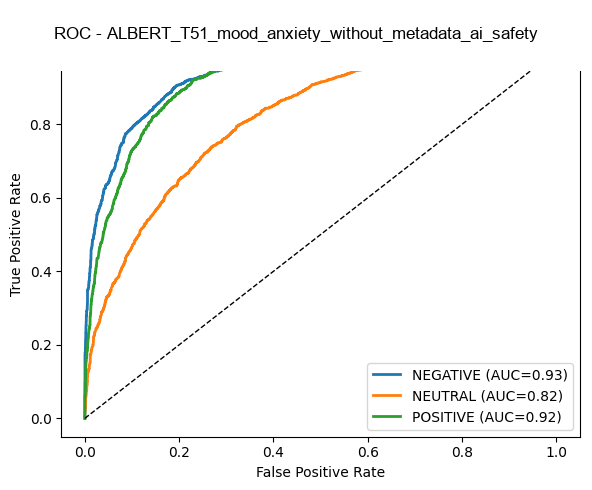

In [ ]:
# @cell:eval
def bootstrap_f1_ci(y_true, y_pred, n=1000, average='weighted'):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred); s = []
    for _ in range(n):
        idx = resample(np.arange(len(y_true)))
        try:
            s.append(f1_score(y_true[idx], y_pred[idx], average=average))
        except ValueError:
            continue
    return (float(np.mean(s)), float(np.percentile(s, 2.5)), float(np.percentile(s, 97.5))) if s else (np.nan,)*3

def bootstrap_auc_ci(y_true, y_prob, n=1000):
    y_true = np.asarray(y_true); y_prob = np.asarray(y_prob); s = []
    for _ in range(n):
        idx = resample(np.arange(len(y_true)))
        try:
            s.append(roc_auc_score(y_true[idx], y_prob[idx], average='macro', multi_class='ovr'))
        except ValueError:
            continue
    return (float(np.mean(s)), float(np.percentile(s, 2.5)), float(np.percentile(s, 97.5))) if s else (np.nan,)*3

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_ASPECT_CLASSES)))
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=ASPECT_CLASSES, yticklabels=ASPECT_CLASSES)
    plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title(f'Confusion Matrix - {title}')
    plt.tight_layout(); plt.savefig(OUTPUT_PATH / f'{title}_confusion_matrix.png', dpi=200); plt.show()

def plot_multiclass_roc(y_true, y_prob, title):
    y_bin = label_binarize(y_true, classes=list(range(NUM_ASPECT_CLASSES)))
    plt.figure(figsize=(6, 5))
    for i, name in enumerate(ASPECT_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc(fpr, tpr):.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'ROC - {title}'); plt.legend(loc='lower right')
    plt.tight_layout(); plt.savefig(OUTPUT_PATH / f'{title}_roc_curve.png', dpi=200); plt.show()

best_model.eval()
logits_all = {a: [] for a in ASPECT_NAMES}; true_all = {a: [] for a in ASPECT_NAMES}
with torch.no_grad():
    for batch in test_loader:
        ids = batch['input_ids'].to(DEVICE, non_blocking=True)
        mask = batch['attention_mask'].to(DEVICE, non_blocking=True)
        with autocast('cuda', enabled=USE_FP16):
            logits = best_model(ids, mask)
        for a in ASPECT_NAMES:
            logits_all[a].append(logits[a].float().cpu().numpy())
            true_all[a].extend(batch[f'{a}_label'].numpy())

results = {}
for a in ASPECT_NAMES:
    lg = np.concatenate(logits_all[a])
    prob = torch.softmax(torch.tensor(lg), dim=1).numpy()
    pred = prob.argmax(1); true = np.asarray(true_all[a])
    print('=' * 58); print(f'{a}   (3-class: NEGATIVE / NEUTRAL / POSITIVE)'); print('=' * 58)
    print(classification_report(true, pred, labels=list(range(NUM_ASPECT_CLASSES)),
                                target_names=ASPECT_CLASSES, digits=4, zero_division=0))
    f1m, f1lo, f1hi = bootstrap_f1_ci(true, pred)
    aucm, auclo, auchi = bootstrap_auc_ci(true, prob)
    print(f'Accuracy       : {accuracy_score(true, pred):.4f}')
    print(f'Macro F1       : {f1_score(true, pred, average="macro", zero_division=0):.4f}')
    print(f'Weighted F1    : {f1m:.4f}  95% CI [{f1lo:.4f}, {f1hi:.4f}]')
    print(f'Macro AUC (OvR): {aucm:.4f}  95% CI [{auclo:.4f}, {auchi:.4f}]')
    plot_confusion_matrix(true, pred, f'ALBERT_{RUN_ID}_{a}')
    plot_multiclass_roc(true, prob, f'ALBERT_{RUN_ID}_{a}')
    results[a] = {'y_true': true, 'y_pred': pred,
                  'accuracy': float(accuracy_score(true, pred)),
                  'macro_f1': float(f1_score(true, pred, average='macro', zero_division=0)),
                  'weighted_f1': f1m, 'f1_ci': (f1lo, f1hi),
                  'macro_auc': aucm, 'auc_ci': (auclo, auchi)}

## 6. Save predictions & summary

In [ ]:
# @cell:save
cols = [c for c in [TEXT_COLUMN0, 'drugName', 'condition', 'usefulCount'] if c in df_test.columns]
out = df_test[cols].copy()
for a in ASPECT_NAMES:
    out[f'{a}_true'] = results[a]['y_true']
    out[f'{a}_pred'] = results[a]['y_pred']
joint = np.ones(len(df_test), dtype=bool)
for a in ASPECT_NAMES:
    joint &= (results[a]['y_true'] == results[a]['y_pred'])
out['joint_correct'] = joint.astype(int)
pred_path = OUTPUT_PATH / 'test_predictions.csv'
out.to_csv(pred_path, index=False)

summary = {
    'run_id': RUN_ID, 'cohort': COHORT, 'use_metadata': bool(USE_METADATA),
    'data_file': CSV_NAME, 'data_path': str(DATA_PATH),
    'n_train': int(len(df_train)), 'n_val': int(len(df_val)), 'n_test': int(len(df_test)),
    'aspects': {a: {'accuracy': results[a]['accuracy'], 'macro_f1': results[a]['macro_f1'],
                    'weighted_f1': results[a]['weighted_f1'],
                    'f1_ci': [results[a]['f1_ci'][0], results[a]['f1_ci'][1]],
                    'macro_auc': results[a]['macro_auc'],
                    'auc_ci': [results[a]['auc_ci'][0], results[a]['auc_ci'][1]]}
                for a in ASPECT_NAMES},
    'joint_exact_match': float(joint.mean()),
}
json.dump(summary, open(OUTPUT_PATH / 'summary.json', 'w'), indent=2)
print(json.dumps(summary, indent=2))
print('Saved predictions ->', pred_path)

{
  "run_id": "T51_mood_anxiety_without_metadata",
  "cohort": "mood_anxiety",
  "use_metadata": false,
  "data_file": "drugsCom_mood_anxiety_with_ai_labels_mini.csv",
  "data_path": "./R1/T51_mood_anxiety_without_metadata/data/drugsCom_mood_anxiety_with_ai_labels_mini.csv",
  "n_train": 17221,
  "n_val": 5761,
  "n_test": 5773,
  "aspects": {
    "ai_efficacy": {
      "accuracy": 0.852589641434263,
      "macro_f1": 0.7477413282351032,
      "weighted_f1": 0.864362528559156,
      "f1_ci": [
        0.8562441775150752,
        0.8727291836303945
      ],
      "macro_auc": 0.9503003339095417,
      "auc_ci": [
        0.9454381769912056,
        0.9551643568055546
      ]
    },
    "ai_safety": {
      "accuracy": 0.7250996015936255,
      "macro_f1": 0.7223369101820231,
      "weighted_f1": 0.7260625321753026,
      "f1_ci": [
        0.7136920228262372,
        0.7382979844009406
      ],
      "macro_auc": 0.890075472794048,
      "auc_ci": [
        0.8838363836547719,
        0